

# Project : TalentSignal – Labour Market Intelligence

Job market analytics from job postings: skill demand, salary premiums, city demand, rising skills, and a skill gap check against your own skills.

## What this notebook does
- Makes ~5000 made-up job postings (or uses your real job_postings.csv, with a column map you can edit). With made-up data the findings show the method, not the real market
- Counts the most demanded skills and roles
- Finds which skills come with a salary premium, compared inside the same role
- Finds skills that are rising month by month
- Finds which skills appear together
- Compares your skills with each role and shows what to learn next
- Uses Groq AI to write a career signal briefing

## How to run
1. Upload this file to Google Colab (or open it from Drive)
2. Runtime → Run all, or run each cell one by one
3. If a step fails, run the cell again, then restart the runtime once and run again

## Step 1: Install libraries

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn openai

## Step 2: Connect to Groq (the AI part)
Paste your Groq API key when it asks. The key is hidden while you type.

In [2]:
import time
from getpass import getpass
from openai import OpenAI

GROQ_KEY = getpass("Paste your Groq API key: ")
client = OpenAI(api_key=GROQ_KEY, base_url="https://api.groq.com/openai/v1")
MODEL = "openai/gpt-oss-120b"

def ask_llm(question, system="You are a helpful analyst.", model=MODEL):
    for tries in range(3):
        try:
            r = client.chat.completions.create(
                model=model,
                messages=[{"role": "system", "content": system}, {"role": "user", "content": question}],
                max_tokens=1500,
                temperature=0.3,
            )
            return r.choices[0].message.content
        except Exception as e:
            print("llm error, trying again:", str(e)[:100])
            time.sleep(5)
    return "LLM not available right now."

print(ask_llm("Say hi in five words."))

Paste your Groq API key: ··········
Hi there, how are you?


## Step 3: Load the data
Skills are stored as one text like `Python, SQL, Power BI` (comma separated).

In [3]:
import os, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
np.random.seed(3)
sns.set_style("whitegrid")

role_skills = {
    "Data Analyst": ["SQL", "Excel", "Power BI", "Python", "Tableau", "Statistics"],
    "Data Scientist": ["Python", "SQL", "Machine Learning", "Statistics", "Deep Learning", "Pandas"],
    "ML Engineer": ["Python", "Machine Learning", "Deep Learning", "Docker", "AWS", "MLOps"],
    "BI Developer": ["Power BI", "SQL", "Tableau", "Excel", "DAX", "ETL"],
    "Data Engineer": ["SQL", "Python", "Spark", "AWS", "ETL", "Airflow"],
    "AI Engineer": ["Python", "LLM", "RAG", "LangChain", "Docker", "Machine Learning"],
}
role_salary = {"Data Analyst": 6, "Data Scientist": 12, "ML Engineer": 15, "BI Developer": 8, "Data Engineer": 13, "AI Engineer": 16}
city_factor = {"Bengaluru": 1.2, "Hyderabad": 1.1, "Pune": 1.0, "Mumbai": 1.1, "Delhi NCR": 1.1, "Chennai": 0.95, "Remote": 1.05}
premium_skill = {"LLM": 3, "RAG": 3, "MLOps": 2, "Spark": 2, "AWS": 1.5, "Docker": 1, "Deep Learning": 1.5, "LangChain": 2}

def make_jobs(n=5000):
    rows = []
    roles = list(role_skills.keys())
    for i in range(n):
        role = np.random.choice(roles, p=[0.28, 0.2, 0.1, 0.12, 0.15, 0.15])
        date = pd.Timestamp("2025-01-01") + pd.Timedelta(days=int(np.random.randint(0, 365)))
        month_progress = date.month / 12
        pool = role_skills[role]
        k = np.random.randint(3, 6)
        chosen = list(np.random.choice(pool, k, replace=False))
        for general_skill in ["Git", "Communication", "Cloud"]:
            if np.random.rand() < 0.15:
                chosen.append(general_skill)
        # AI skills become more common later in the year
        if np.random.rand() < 0.1 + 0.35 * month_progress and role in ["Data Scientist", "AI Engineer", "Data Analyst"]:
            chosen.append("LLM")
        if np.random.rand() < 0.05 + 0.25 * month_progress and role in ["AI Engineer", "Data Scientist"]:
            chosen.append("RAG")
        chosen = list(set(chosen))
        exp_min = int(np.random.choice([0, 1, 2, 3, 5], p=[0.2, 0.25, 0.25, 0.2, 0.1]))
        salary = role_salary[role] * (1 + exp_min * 0.18) * city_factor[np.random.choice(list(city_factor.keys()))]
        salary = salary + sum(premium_skill.get(s, 0) for s in chosen) * np.random.uniform(0.6, 1.2)
        salary = salary * np.random.normal(1, 0.08)
        rows.append({"title": role, "city": np.random.choice(list(city_factor.keys()), p=[0.25, 0.15, 0.15, 0.15, 0.12, 0.08, 0.1]),
                     "exp_min": exp_min, "salary_lpa": round(salary, 1), "skills": ", ".join(sorted(chosen)), "posted_date": date})
    return pd.DataFrame(rows)

# To use REAL postings: upload a CSV named job_postings.csv and edit the right side of this map to match YOUR column names
column_map = {"title": "title", "city": "city", "salary_lpa": "salary_lpa", "exp_min": "exp_min",
              "skills": "skills", "posted_date": "posted_date"}
needed = list(column_map.keys())

jobs = None
data_source = "made-up postings"
if os.path.exists("job_postings.csv"):
    raw_jobs = pd.read_csv("job_postings.csv")
    missing = [v for v in column_map.values() if v not in raw_jobs.columns]
    if len(missing) > 0:
        print("Your job_postings.csv is missing these columns:", missing, "- edit column_map above. Using made-up data for now.")
    else:
        jobs = raw_jobs.rename(columns={v: k for k, v in column_map.items()})[needed].copy()
        jobs["posted_date"] = pd.to_datetime(jobs["posted_date"])
        jobs = jobs.dropna(subset=["title", "skills", "salary_lpa"])
        data_source = "your job_postings.csv"
        print("Using your job_postings.csv")
if jobs is None:
    jobs = make_jobs()
    print("Using made-up postings. The patterns below come from rules written into the generator, so they show the METHOD, not the real job market.")

jobs["month"] = jobs["posted_date"].dt.to_period("M").astype(str)
jobs["skill_list"] = jobs["skills"].apply(lambda x: [s.strip() for s in str(x).split(",")])
print(jobs.shape)
jobs.head()

Using made-up postings. The patterns below come from rules written into the generator, so they show the METHOD, not the real job market.
(5000, 8)


,title,city,exp_min,salary_lpa,skills,posted_date,month,skill_list
0,ML Engineer,Mumbai,0,21.2,"AWS, Communication, Deep Learning, Docker",2025-09-07,2025-09,"[AWS, Communication, Deep Learning, Docker]"
1,Data Analyst,Remote,1,7.1,"Power BI, Python, Statistics, Tableau",2025-12-13,2025-12,"[Power BI, Python, Statistics, Tableau]"
2,AI Engineer,Mumbai,1,22.6,"Docker, LangChain, Machine Learning, RAG",2025-02-24,2025-02,"[Docker, LangChain, Machine Learning, RAG]"
3,BI Developer,Chennai,2,11.9,"DAX, Excel, Git, Tableau",2025-10-02,2025-10,"[DAX, Excel, Git, Tableau]"
4,ML Engineer,Bengaluru,0,17.7,"Deep Learning, Docker, Machine Learning",2025-11-09,2025-11,"[Deep Learning, Docker, Machine Learning]"


## Step 4: Most demanded roles and skills

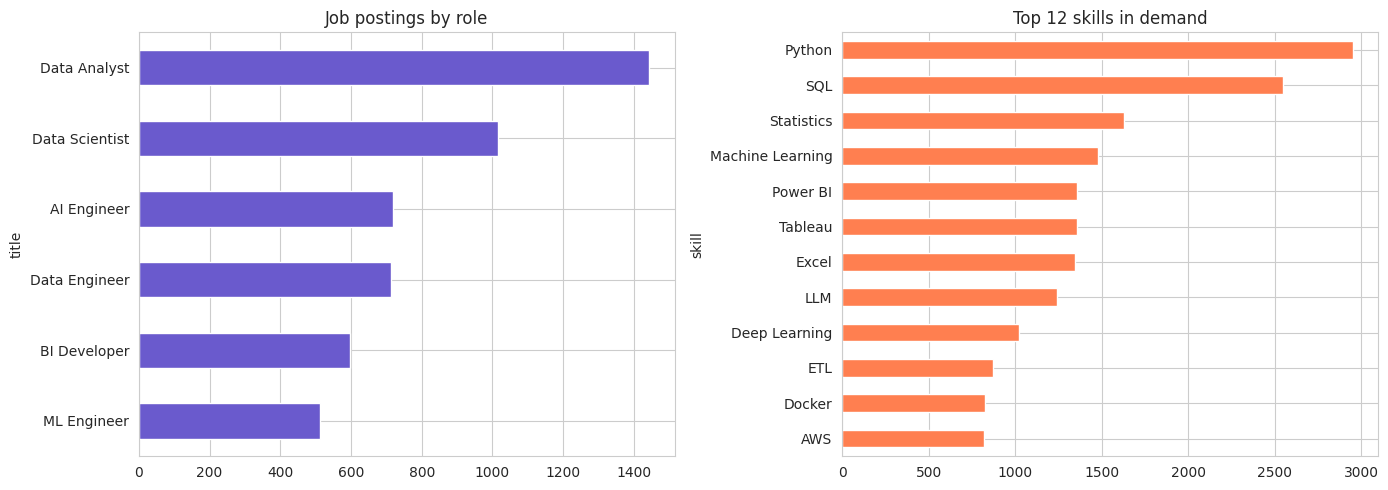

Share of postings asking for each top skill (%):
skill
Python              59.0
SQL                 50.9
Statistics          32.6
Machine Learning    29.6
Power BI            27.2
Tableau             27.1
Excel               26.9
LLM                 24.8
Deep Learning       20.5
ETL                 17.5
Name: count, dtype: float64


In [4]:
skills_long = jobs.explode("skill_list").rename(columns={"skill_list": "skill"})
skill_counts = skills_long["skill"].value_counts()
role_counts = jobs["title"].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
role_counts.sort_values().plot(kind="barh", ax=ax[0], color="slateblue")
ax[0].set_title("Job postings by role")
skill_counts.head(12).sort_values().plot(kind="barh", ax=ax[1], color="coral")
ax[1].set_title("Top 12 skills in demand")
plt.tight_layout()
plt.show()

print("Share of postings asking for each top skill (%):")
print((skill_counts.head(10) / len(jobs) * 100).round(1))

## Step 5: Salary by role, city and skill premium

                median  mean  count
title                              
AI Engineer       28.0  28.8    718
ML Engineer       24.4  25.2    513
Data Engineer     19.9  20.5    714
Data Scientist    18.9  19.3   1015
BI Developer      11.3  11.5    596
Data Analyst       9.0   9.3   1444

           postings  median_salary
city                              
Bengaluru      1198           16.8
Hyderabad       789           16.9
Pune            755           16.5
Mumbai          735           17.3
Delhi NCR       601           17.1
Remote          482           17.4
Chennai         440           17.2

Skill salary premium (LPA). premium_lpa compares jobs of the SAME role, raw_premium_lpa mixes roles:
           skill  postings  raw_premium_lpa  premium_lpa  roles_compared
0            RAG       738             11.7          2.5               2
1            LLM      1240              5.8          2.5               3
2      LangChain       479             12.8          1.7               1
3 

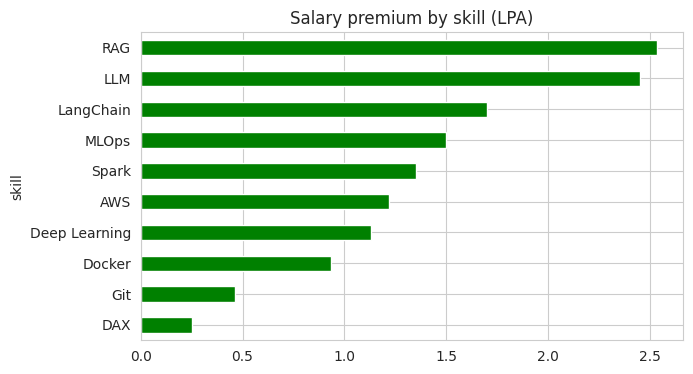

In [5]:
role_salary_table = jobs.groupby("title")["salary_lpa"].agg(["median", "mean", "count"]).round(1).sort_values("median", ascending=False)
city_table = jobs.groupby("city").agg(postings=("title", "count"), median_salary=("salary_lpa", "median")).sort_values("postings", ascending=False).round(1)
print(role_salary_table)
print()
print(city_table)

rows = []
for s in skill_counts.index:
    has_all = jobs[jobs["skills"].str.contains(s, regex=False)]["salary_lpa"]
    no_all = jobs[~jobs["skills"].str.contains(s, regex=False)]["salary_lpa"]
    if len(has_all) < 50 or len(no_all) < 50:
        continue
    diffs = []
    weights = []
    for role in jobs["title"].unique():
        r = jobs[jobs["title"] == role]
        has = r[r["skills"].str.contains(s, regex=False)]["salary_lpa"]
        no = r[~r["skills"].str.contains(s, regex=False)]["salary_lpa"]
        if len(has) >= 30 and len(no) >= 30:
            diffs.append(has.median() - no.median())
            weights.append(len(has))
    if len(diffs) == 0:
        continue
    rows.append({"skill": s, "postings": len(has_all), "raw_premium_lpa": has_all.median() - no_all.median(),
                 "premium_lpa": float(np.average(diffs, weights=weights)), "roles_compared": len(diffs)})
premium = pd.DataFrame(rows).sort_values("premium_lpa", ascending=False).reset_index(drop=True)
print("\nSkill salary premium (LPA). premium_lpa compares jobs of the SAME role, raw_premium_lpa mixes roles:")
print(premium.round(1).head(10))
print("\nA big gap between raw_premium_lpa and premium_lpa means the skill mostly signals the role, not extra pay. Even the within-role number is a signal, not proof that the skill causes higher pay.")

premium.head(10).sort_values("premium_lpa").plot(kind="barh", x="skill", y="premium_lpa", figsize=(7, 4), color="green", legend=False)
plt.title("Salary premium by skill (LPA)")
plt.show()

## Step 6: Rising skills (month by month)

              skill  early_share_pct  recent_share_pct  change_pts
0               LLM             16.6              31.5        14.9
1               RAG             12.2              17.6         5.4
2  Machine Learning             28.7              30.6         1.9
3     Deep Learning             19.4              20.6         1.2
4            Docker             16.4              17.4         1.0
5          Power BI             26.3              27.2         0.9

Falling skills:
      skill  early_share_pct  recent_share_pct  change_pts
19      ETL             18.4              16.8        -1.5
20    Spark             11.1               9.5        -1.6
21  Airflow             11.1               8.5        -2.6


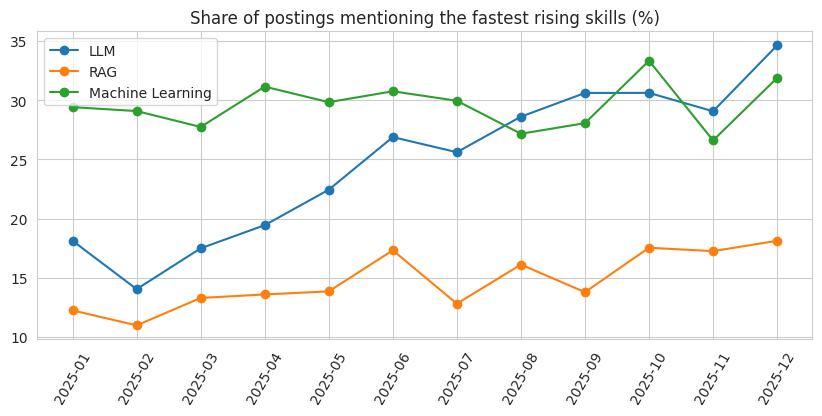

In [6]:
months = sorted(jobs["month"].unique())
first_months = months[:3]
last_months = months[-3:]
first_jobs = jobs[jobs["month"].isin(first_months)]
last_jobs = jobs[jobs["month"].isin(last_months)]

rows = []
for s in skill_counts.index:
    a = first_jobs["skills"].str.contains(s, regex=False).mean() * 100
    b = last_jobs["skills"].str.contains(s, regex=False).mean() * 100
    rows.append({"skill": s, "early_share_pct": a, "recent_share_pct": b, "change_pts": b - a})
trend = pd.DataFrame(rows).sort_values("change_pts", ascending=False).reset_index(drop=True)
print(trend.round(1).head(6))
print("\nFalling skills:")
print(trend.round(1).tail(3))

top_rising = trend["skill"].head(3).tolist()
plt.figure(figsize=(10, 4))
for s in top_rising:
    share = jobs.groupby("month")["skills"].apply(lambda x: x.str.contains(s, regex=False).mean() * 100)
    plt.plot(share.index, share.values, marker="o", label=s)
plt.xticks(rotation=60)
plt.legend()
plt.title("Share of postings mentioning the fastest rising skills (%)")
plt.show()

## Step 7: Skills that appear together

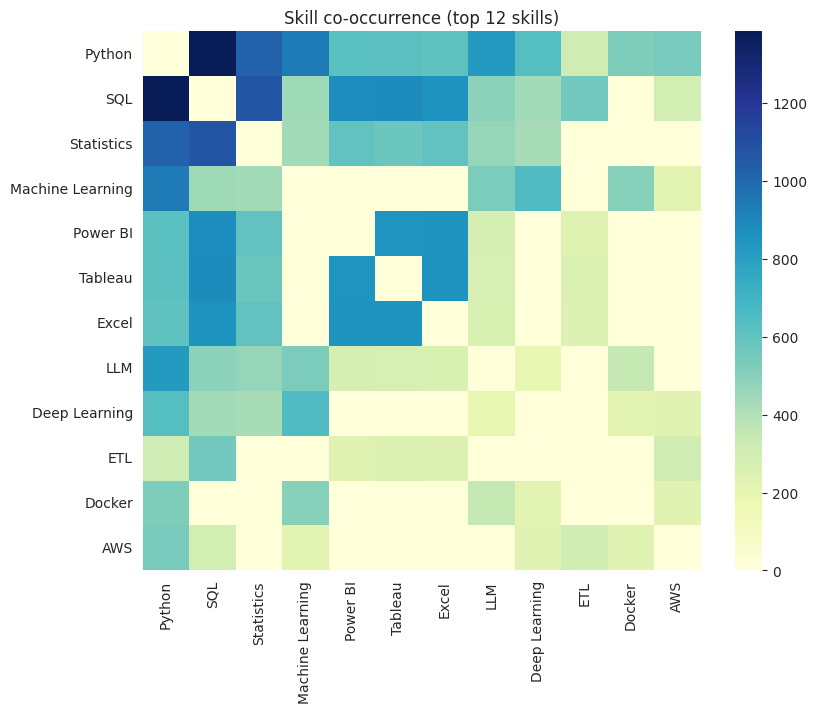

In [7]:
top_skills = skill_counts.head(12).index.tolist()
matrix = pd.DataFrame(0, index=top_skills, columns=top_skills)
for lst in jobs["skill_list"]:
    for a, b in itertools.permutations([s for s in lst if s in top_skills], 2):
        matrix.loc[a, b] += 1

plt.figure(figsize=(9, 7))
sns.heatmap(matrix, cmap="YlGnBu")
plt.title("Skill co-occurrence (top 12 skills)")
plt.show()

## Step 8: Skill gap check
Edit `my_skills` to your own list. Match % = how many of a role's most asked skills you already have.

In [8]:
my_skills = ["Python", "SQL", "Power BI", "Excel", "Pandas", "Machine Learning", "Statistics", "LangChain", "RAG"]

rows = []
gap_by_role = {}
for role in jobs["title"].unique():
    role_jobs = jobs[jobs["title"] == role]
    freq = role_jobs.explode("skill_list")["skill_list"].value_counts() / len(role_jobs)
    important = freq[freq >= 0.25]
    have = [s for s in important.index if s in my_skills]
    missing = [s for s in important.index if s not in my_skills]
    match = len(have) / max(len(important), 1) * 100
    rows.append({"role": role, "important_skills": len(important), "you_have": len(have), "match_pct": round(match, 0), "missing": ", ".join(missing[:4])})
    gap_by_role[role] = missing
gap = pd.DataFrame(rows).sort_values("match_pct", ascending=False).reset_index(drop=True)
print(gap)

fresher_share = (jobs["exp_min"] == 0).mean() * 100
print("\nFresher-friendly postings (exp_min = 0):", round(fresher_share, 1), "%")
print(jobs[jobs["exp_min"] == 0].groupby("title").size().sort_values(ascending=False))

             role  important_skills  you_have  match_pct  \
0    Data Analyst                 7         5       71.0   
1  Data Scientist                 7         5       71.0   
2     AI Engineer                 6         4       67.0   
3    BI Developer                 6         3       50.0   
4     ML Engineer                 6         2       33.0   
5   Data Engineer                 6         2       33.0   

                             missing  
0                       Tableau, LLM  
1                 Deep Learning, LLM  
2                        LLM, Docker  
3                  Tableau, DAX, ETL  
4  Deep Learning, AWS, Docker, MLOps  
5           ETL, Airflow, Spark, AWS  

Fresher-friendly postings (exp_min = 0): 20.4 %
title
Data Analyst      303
Data Scientist    195
AI Engineer       149
Data Engineer     143
BI Developer      124
ML Engineer       108
dtype: int64


## Step 9: AI career signal briefing (Groq)

In [9]:
text = f"""
Data source: {data_source}
Total postings: {len(jobs)}
Top roles: {role_counts.head(4).to_dict()}
Top skills (share of postings %): {(skill_counts.head(8) / len(jobs) * 100).round(1).to_dict()}
Highest salary premium skills within the same role (LPA): {premium.head(5)[['skill', 'premium_lpa', 'raw_premium_lpa']].round(1).to_dict('records')}
Fastest rising skills (change in share, points): {trend.head(4)[['skill', 'change_pts']].round(1).to_dict('records')}
Fresher-friendly postings: {fresher_share:.1f}%
Candidate skills: {my_skills}
Role match and missing skills: {gap[['role', 'match_pct', 'missing']].to_dict('records')}
"""
brief = ask_llm("Write a career signal briefing for a fresher data professional: what the market wants, which role fits best now, which 3 skills to learn next and why. Use only these numbers. Weigh both demand and salary premium, do not claim a skill CAUSES higher pay, and if the data source says made-up, state once that the findings only show the method.\n" + text,
                system="You are a labour market analyst. Do not invent numbers.")
print(brief)

**Career‑Signal Briefing – Fresher Data Professional**  
*Source: “made‑up” job‑posting dataset (5 000 postings). The figures below reflect what the data show; they do not prove that any skill *causes* higher pay.*

---

### 1. What the market wants  

| Role (postings) | Share of total postings* | Fresher‑friendly share |
|-----------------|--------------------------|------------------------|
| Data Analyst | 1 444 (~28.9 %) | – |
| Data Scientist | 1 015 (~20.3 %) | – |
| AI Engineer | 718 (~14.4 %) | – |
| Data Engineer | 714 (~14.3 %) | – |
| **All other roles** | 1 109 (~22.2 %) | – |

\*Share = postings ÷ 5 000 × 100.  

**Top technical skills appearing in postings (share of postings)**  

| Skill | Share of postings |
|-------|-------------------|
| Python | 59.0 % |
| SQL | 50.9 % |
| Statistics | 32.6 % |
| Machine Learning | 29.6 % |
| Power BI | 27.2 % |
| Tableau | 27.1 % |
| Excel | 26.9 % |
| LLM (large‑language‑model) | 24.8 % |

**Salary‑premium signals (within the same

## Step 10: Key insights and export

In [10]:
print("KEY INSIGHTS (calculated from this run)")
print("1. Most demanded role:", role_counts.index[0], "-", role_counts.iloc[0], "postings")
print("2. Most demanded skill:", skill_counts.index[0], "-", round(skill_counts.iloc[0] / len(jobs) * 100, 1), "% of postings")
print("3. Highest within-role salary premium:", premium.loc[0, "skill"], "- about", round(premium.loc[0, "premium_lpa"], 1), "LPA (raw gap", round(premium.loc[0, "raw_premium_lpa"], 1), "LPA)")
print("4. Fastest rising skill:", trend.loc[0, "skill"], "- up", round(trend.loc[0, "change_pts"], 1), "points")
print("5. Best role match for your skills:", gap.loc[0, "role"], "-", gap.loc[0, "match_pct"], "%")
print("6. Data source:", data_source)
if data_source == "made-up postings":
    print("   These results come from rules written into the data generator, so they show the method and not the real job market.")

jobs.drop(columns=["skill_list"]).to_csv("talentsignal_jobs.csv", index=False)
skills_long[["title", "city", "salary_lpa", "month", "skill"]].to_csv("talentsignal_skills_long.csv", index=False)
premium.to_csv("talentsignal_skill_premium.csv", index=False)
print("\nSaved talentsignal_jobs.csv, talentsignal_skills_long.csv, talentsignal_skill_premium.csv")

KEY INSIGHTS (calculated from this run)
1. Most demanded role: Data Analyst - 1444 postings
2. Most demanded skill: Python - 59.0 % of postings
3. Highest within-role salary premium: RAG - about 2.5 LPA (raw gap 11.7 LPA)
4. Fastest rising skill: LLM - up 14.9 points
5. Best role match for your skills: Data Analyst - 71.0 %
6. Data source: made-up postings
   These results come from rules written into the data generator, so they show the method and not the real job market.

Saved talentsignal_jobs.csv, talentsignal_skills_long.csv, talentsignal_skill_premium.csv



---
Built by **Akshat Kesharwani** | [GitHub](https://github.com/akshatkesharwani-info) | [Portfolio](https://akshatkesharwani-info.github.io/)